# 07 — Calibration robustness check

**Purpose:** Test whether spatial multiplicity (variance, Moran's I, LISA hotspots) is driven by probability miscalibration across model families.

- Uses **only saved artifacts** (no retraining, same Rashomon selection).
- **Platt scaling** (LogisticRegression on predicted probabilities) fitted on **validation set only**; applied to test predictions.
- Recompute multiplicity and spatial metrics on calibrated predictions and compare to uncalibrated.

## 1. Calibration procedure

For each run:
1. Select Rashomon models (top-K by validation Brier from meta.csv).
2. For each selected model: fit **Platt scaling** (sklearn LogisticRegression on predicted probabilities) using **validation** (P_val, y_val) only.
3. Apply the fitted mapping to **test** probabilities (P_test). Test labels are never used.
4. Produce calibrated test matrix P_test_calibrated (n_models, n_test).

Then recompute on calibrated P: mean variance, ambiguity, disagreement rate (ε=0.05), discrepancy, pointwise variance, Moran's I (k=30), LISA HH masks, HH count, component sizes, and Jaccard(HH_before, HH_after).

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.calibration import calibration_curve
from analysis.experiment_runner import _get_run_dirs
from analysis.calibration import run_calibration_experiment, calibrate_predictions_for_run, _get_test_labels
from analysis.preprocessing import get_transformed_test_features
from analysis.run_analysis import pointwise_variance, spatial_analysis

RESULTS_DIR = ROOT / "results"
FIG_DIR = ROOT / "figures"
TABLE_DIR = ROOT / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)
K = 25
dataset_dirs = [p for p in RESULTS_DIR.iterdir() if p.is_dir() and _get_run_dirs(p)]

per_run_list = []
summary_list = []
for dataset_dir in dataset_dirs:
    dataset_name = dataset_dir.name
    
    if "synthetic" in dataset_name:
        continue

    per_run_d, summary_d = run_calibration_experiment(
        dataset_dir,
        dataset_name=dataset_name,
        K=K,
        k_nn=30,
        epsilon=0.05,
    )
    per_run_d = per_run_d.assign(dataset=dataset_name)
    summary_d = summary_d.assign(dataset=dataset_name)
    per_run_list.append(per_run_d)
    summary_list.append(summary_d)

per_run_df = pd.concat(per_run_list, ignore_index=True)
summary_df = pd.concat(summary_list, ignore_index=True)
print(f"Total runs: {len(per_run_df)} (datasets: {', '.join(per_run_df['dataset'].unique())})")
print("Per-dataset CSVs saved under each dataset dir: calibration_summary_per_run.csv, calibration_summary.csv")

c:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\.venv\Lib\site-packages\libpysal\weights\distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)
c:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\.venv\Lib\site-packages\libpysal\weights\distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)
c:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\.venv\Lib\site-packages\libpysal\weights\distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)
c:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\.venv\Lib\site-packages\libpysal\weights\distance.py:153: UserWarning: The weig

Total runs: 40 (datasets: adult, breast_cancer, compas, german)
Per-dataset CSVs saved under each dataset dir: calibration_summary_per_run.csv, calibration_summary.csv


## 2. Metric comparison table

Before vs after calibration (per run) and aggregated Δ (mean ± std).

In [2]:
display(per_run_df)
print("\nAggregated (mean ± std over runs):")
display(summary_df)

,run,brier_before,brier_after,brier_improvement,mean_variance_before,mean_variance_after,delta_mean_variance,mean_conflict_before,mean_conflict_after,delta_mean_conflict,...,disagreement_rate_before,disagreement_rate_after,discrepancy_before,discrepancy_after,jaccard_HH_before_after,n_components_before,n_components_after,max_component_size_before,max_component_size_after,dataset
0,seed=0,0.088879,0.091190,-2.311148e-03,0.001461,0.001754,0.000293,0.016501,0.016100,-0.000401,...,0.138746,0.120992,0.045692,0.038608,0.459459,4,3,18,49,adult
1,seed=1,0.087408,0.089357,-1.948318e-03,0.001306,0.001560,0.000253,0.016747,0.015797,-0.000950,...,0.142327,0.122541,0.054616,0.043683,0.555270,4,2,154,259,adult
2,seed=2,0.087919,0.090867,-2.947316e-03,0.001474,0.001764,0.000290,0.018008,0.017173,-0.000835,...,0.151163,0.124220,0.061630,0.048988,0.396285,5,5,90,147,adult
3,seed=3,0.089963,0.092539,-2.576544e-03,0.001587,0.001890,0.000303,0.019060,0.018045,-0.001015,...,0.159343,0.131639,0.056750,0.047307,0.398671,4,5,92,129,adult
4,seed=4,0.088864,0.091480,-2.615772e-03,0.001433,0.001689,0.000256,0.018135,0.017336,-0.000798,...,0.150443,0.126074,0.053568,0.044013,0.351682,5,4,97,144,adult
5,seed=5,0.088905,0.091912,-3.006964e-03,0.001454,0.001779,0.000325,0.017500,0.017140,-0.000360,...,0.144945,0.125641,0.045694,0.040231,0.448669,6,3,81,157,adult
6,seed=6,0.088166,0.090833,-2.666415e-03,0.001150,0.001516,0.000366,0.016358,0.015367,-0.000991,...,0.127509,0.114724,0.048115,0.039384,0.350711,4,6,60,73,adult
7,seed=7,0.087939,0.090353,-2.413537e-03,0.001444,0.001855,0.000411,0.017983,0.017578,-0.000405,...,0.150763,0.131060,0.062544,0.052156,0.479218,4,4,190,289,adult
8,seed=8,0.088252,0.091098,-2.845523e-03,0.001278,0.001613,0.000335,0.016038,0.015744,-0.000295,...,0.122429,0.112236,0.043926,0.037486,0.455357,2,3,32,45,adult
9,seed=9,0.089453,0.092059,-2.606066e-03,0.001244,0.001542,0.000298,0.015776,0.015568,-0.000209,...,0.135728,0.118331,0.053630,0.044493,0.372294,3,6,59,85,adult



Aggregated (mean ± std over runs):


,metric,mean,std,mean_plus_minus_std,dataset
0,delta_mean_variance,0.000313,0.000049,0.0003 ± 0.0000,adult
1,delta_moran_i,0.001906,0.006744,0.0019 ± 0.0067,adult
2,delta_n_HH,15.000000,27.988093,15.0000 ± 27.9881,adult
3,jaccard_HH_before_after,0.426762,0.064754,0.4268 ± 0.0648,adult
4,brier_improvement,-0.002594,0.000315,-0.0026 ± 0.0003,adult
5,delta_mean_variance,0.002112,0.001775,0.0021 ± 0.0018,breast_cancer
6,delta_moran_i,-0.012794,0.022489,-0.0128 ± 0.0225,breast_cancer
7,delta_n_HH,-1.200000,2.820559,-1.2000 ± 2.8206,breast_cancer
8,jaccard_HH_before_after,0.808333,0.355838,0.8083 ± 0.3558,breast_cancer
9,brier_improvement,-0.000342,0.002015,-0.0003 ± 0.0020,breast_cancer


## 3. Spatial comparison plots

Compare Moran's I and HH count before vs after calibration across runs.

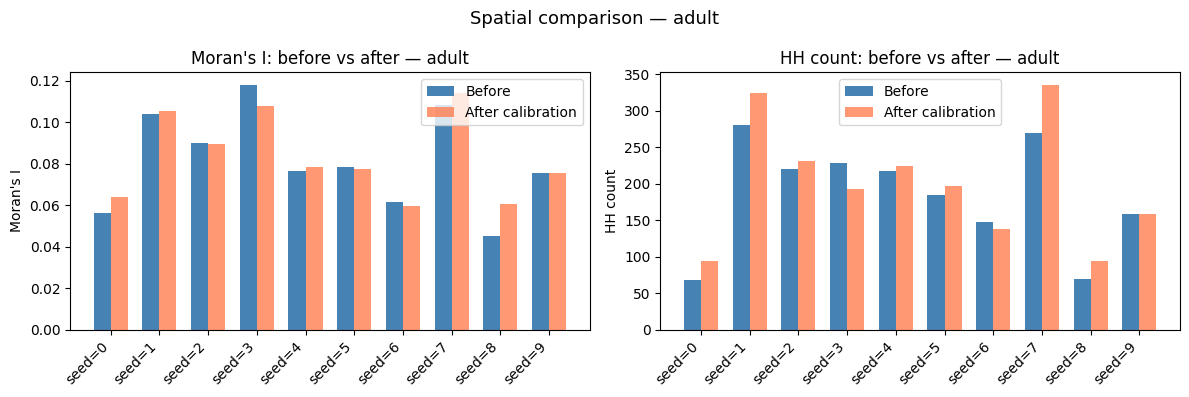

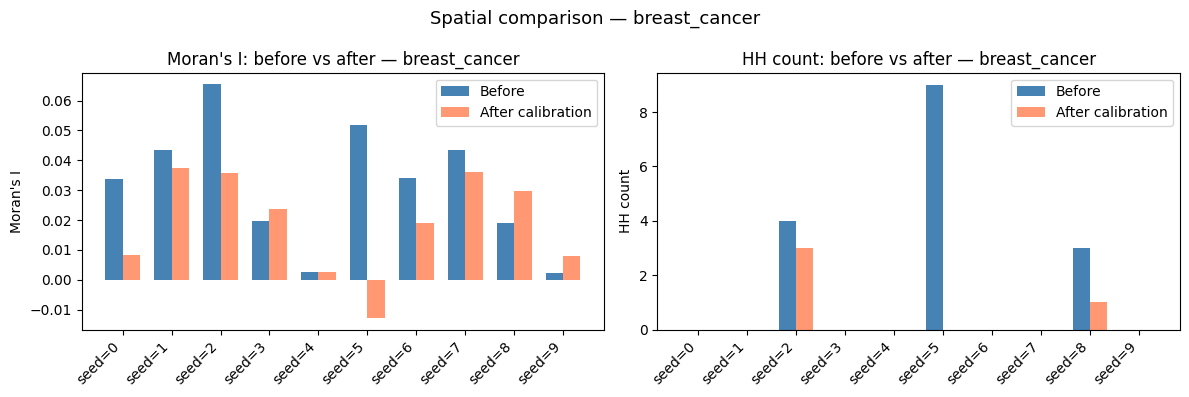

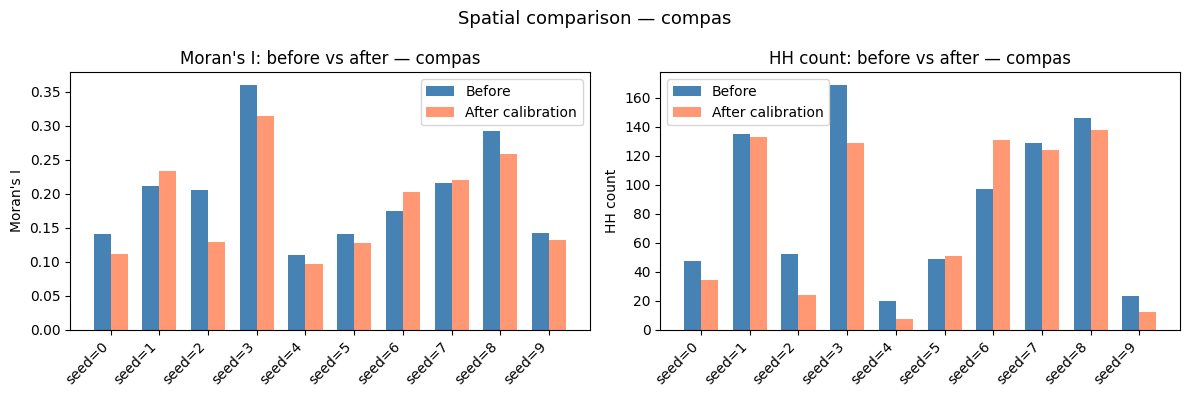

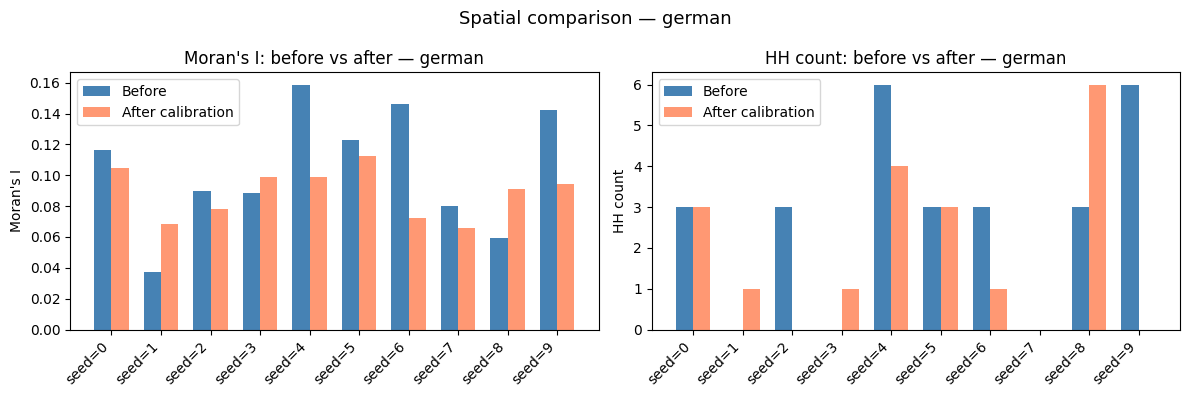

In [3]:
for ds_name, ds_df in per_run_df.groupby("dataset"):
    runs = ds_df["run"].values
    x = np.arange(len(runs))
    w = 0.35

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].bar(x - w/2, ds_df["moran_i_before"], width=w, label="Before", color="steelblue")
    axes[0].bar(x + w/2, ds_df["moran_i_after"], width=w, label="After calibration", color="coral", alpha=0.8)
    axes[0].set_xticks(x); axes[0].set_xticklabels(runs, rotation=45, ha="right")
    axes[0].set_ylabel("Moran's I"); axes[0].set_title(f"Moran's I: before vs after — {ds_name}")
    axes[0].legend()

    axes[1].bar(x - w/2, ds_df["n_HH_before"], width=w, label="Before", color="steelblue")
    axes[1].bar(x + w/2, ds_df["n_HH_after"], width=w, label="After calibration", color="coral", alpha=0.8)
    axes[1].set_xticks(x); axes[1].set_xticklabels(runs, rotation=45, ha="right")
    axes[1].set_ylabel("HH count"); axes[1].set_title(f"HH count: before vs after — {ds_name}")
    axes[1].legend()

    fig.suptitle(f"Spatial comparison — {ds_name}", fontsize=13)
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"calibration_spatial_comparison_{ds_name}.pdf", bbox_inches="tight")
    plt.show()

## 4. Jaccard overlap analysis

Jaccard(HH_before, HH_after) measures how much the set of HH hotspots changes after calibration. High overlap → similar hotspots; low overlap → calibration shifts where hotspots appear.

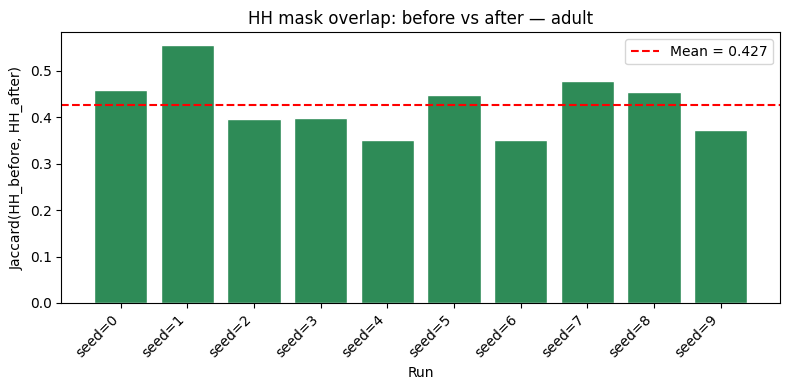

adult: Jaccard = 0.4268 ± 0.0648


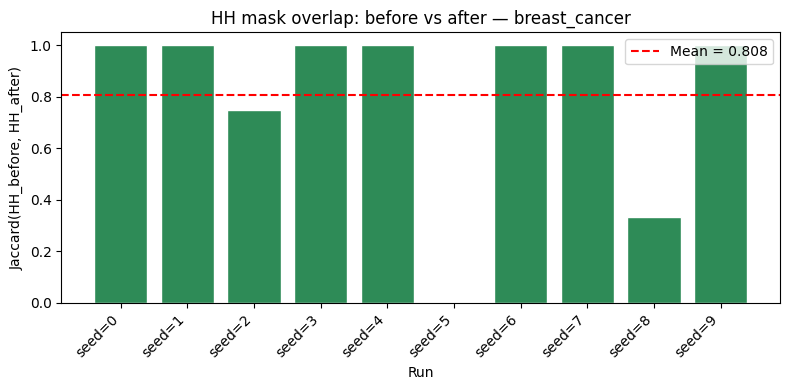

breast_cancer: Jaccard = 0.8083 ± 0.3558


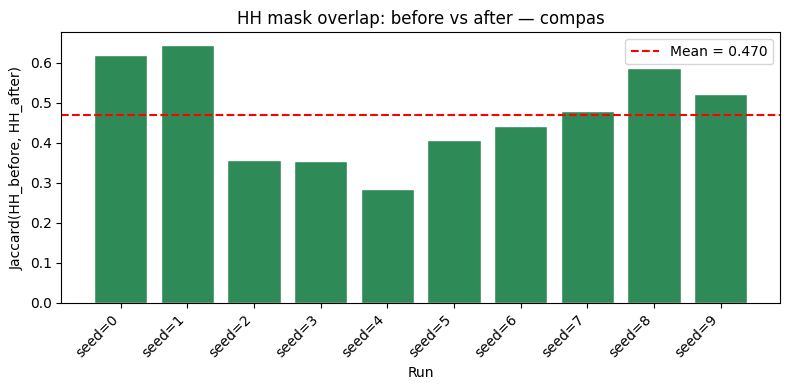

compas: Jaccard = 0.4701 ± 0.1219


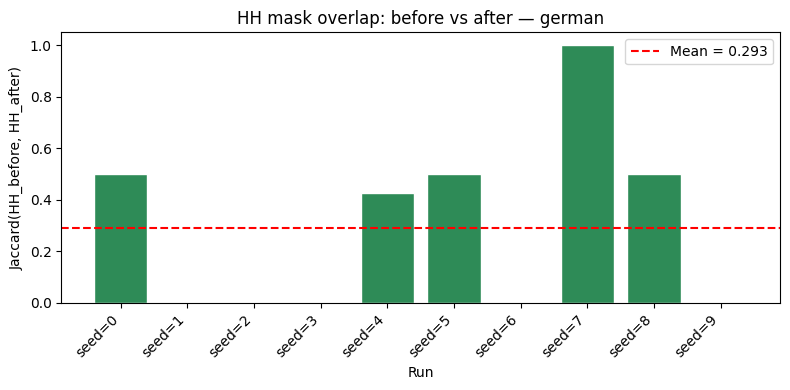

german: Jaccard = 0.2929 ± 0.3458


In [4]:
for ds_name, ds_df in per_run_df.groupby("dataset"):
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(ds_df["run"], ds_df["jaccard_HH_before_after"], color="seagreen", edgecolor="white")
    mean_j = ds_df["jaccard_HH_before_after"].mean()
    ax.axhline(mean_j, color="red", ls="--", label=f"Mean = {mean_j:.3f}")
    ax.set_ylabel("Jaccard(HH_before, HH_after)")
    ax.set_xlabel("Run")
    ax.set_title(f"HH mask overlap: before vs after — {ds_name}")
    ax.legend()
    plt.xticks(rotation=45, ha="right")
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"calibration_jaccard_{ds_name}.pdf", bbox_inches="tight")
    plt.show()
    print(f"{ds_name}: Jaccard = {mean_j:.4f} ± {ds_df['jaccard_HH_before_after'].std():.4f}")

## 5. Delta distributions

Boxplots of calibration-induced changes across seeds for each dataset: Δ mean_variance, Δ Moran's I, Δ HH count, and Jaccard(HH_before, HH_after).

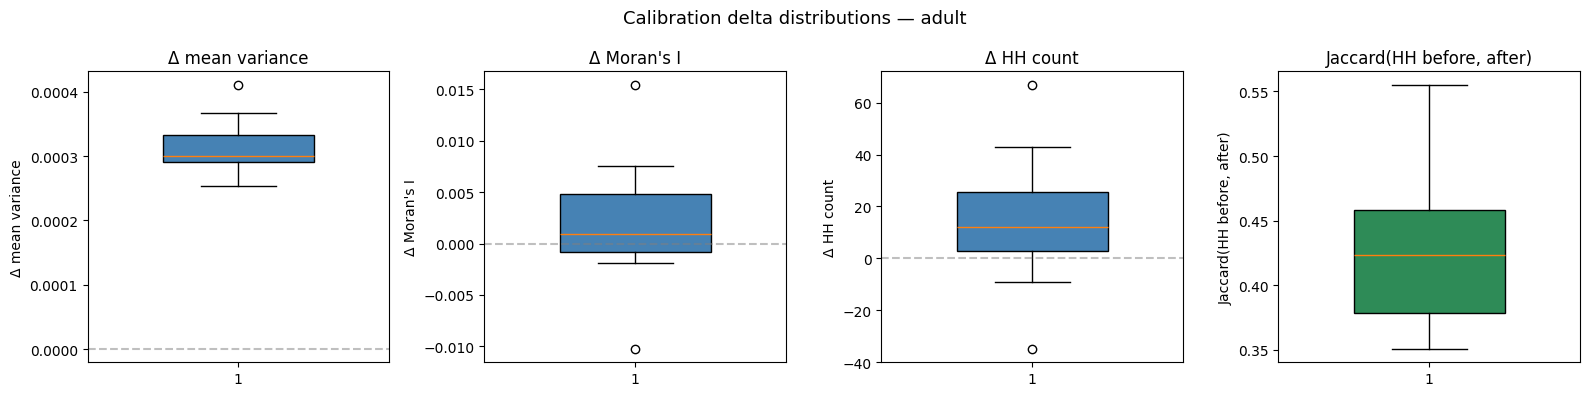

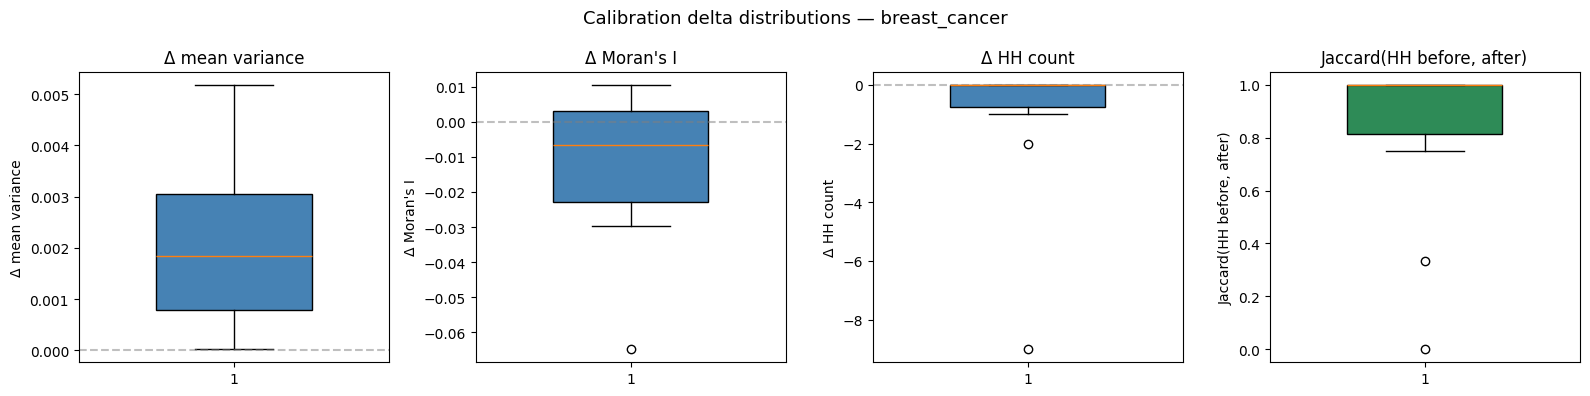

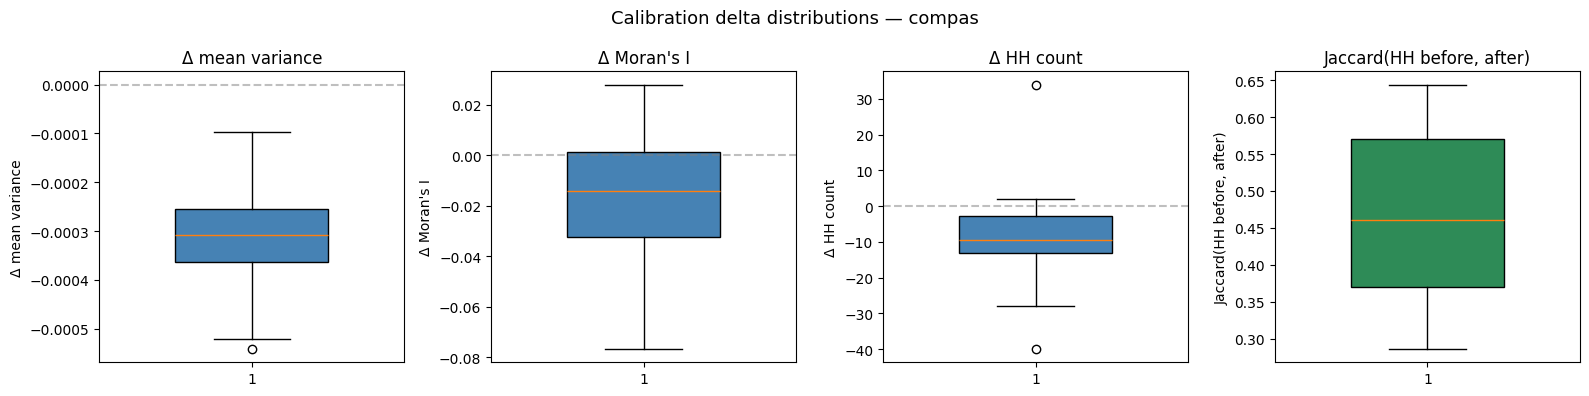

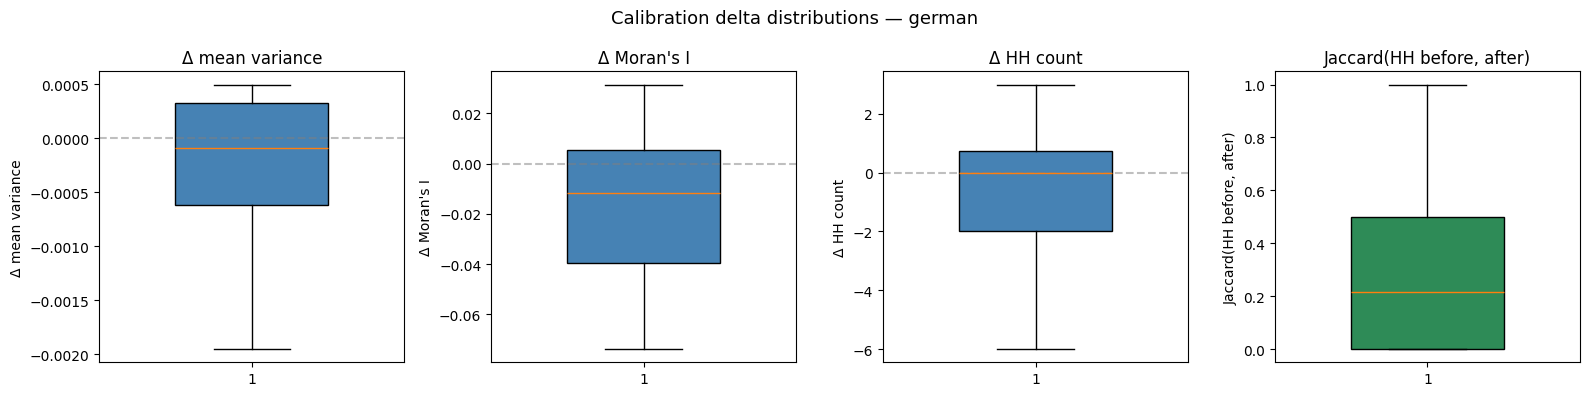

In [5]:
delta_cols = [
    ("delta_mean_variance", "Δ mean variance"),
    ("delta_moran_i", "Δ Moran's I"),
    ("delta_n_HH", "Δ HH count"),
    ("jaccard_HH_before_after", "Jaccard(HH before, after)"),
]

for ds_name, ds_df in per_run_df.groupby("dataset"):
    fig, axes = plt.subplots(1, len(delta_cols), figsize=(4 * len(delta_cols), 4))
    for ax, (col, label) in zip(axes, delta_cols):
        vals = ds_df[col].dropna().values
        bp = ax.boxplot(vals, patch_artist=True, widths=0.5)
        bp["boxes"][0].set_facecolor("steelblue" if "Jaccard" not in label else "seagreen")
        ax.set_ylabel(label)
        ax.set_title(label)
        if "Jaccard" not in label:
            ax.axhline(0, color="gray", ls="--", alpha=0.5)
    fig.suptitle(f"Calibration delta distributions — {ds_name}", fontsize=13)
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"calibration_delta_metrics_{ds_name}.pdf", bbox_inches="tight")
    plt.show()

## 6. Reliability / calibration curves

For a representative run per dataset, plot the reliability curve of the ensemble mean probability before and after Platt scaling.

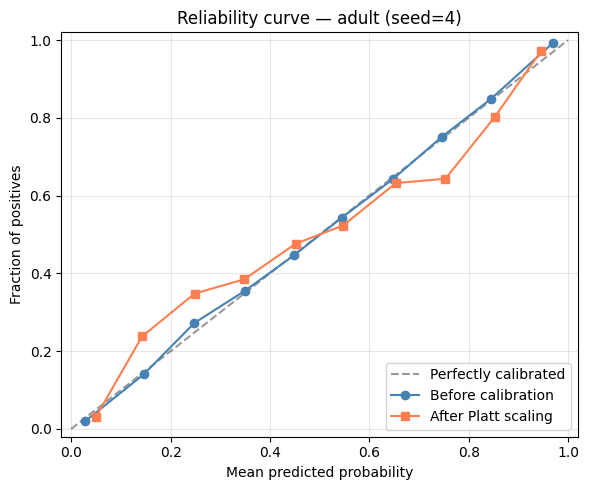

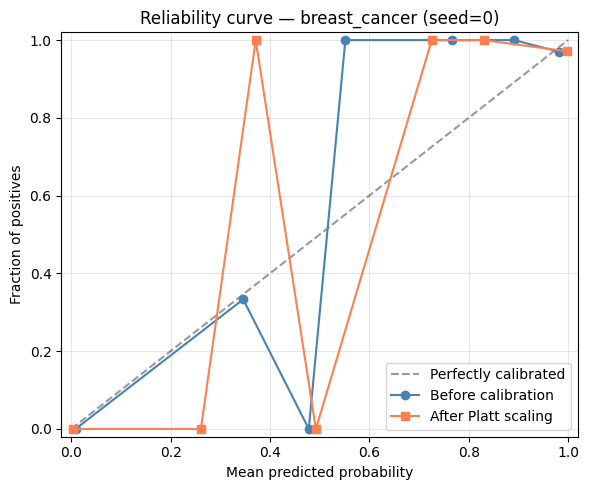

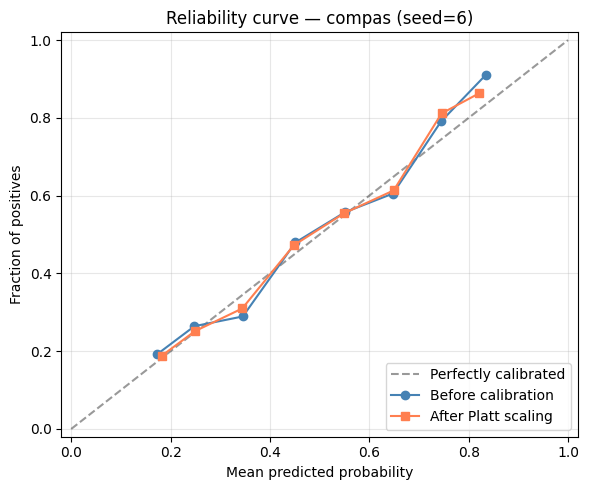

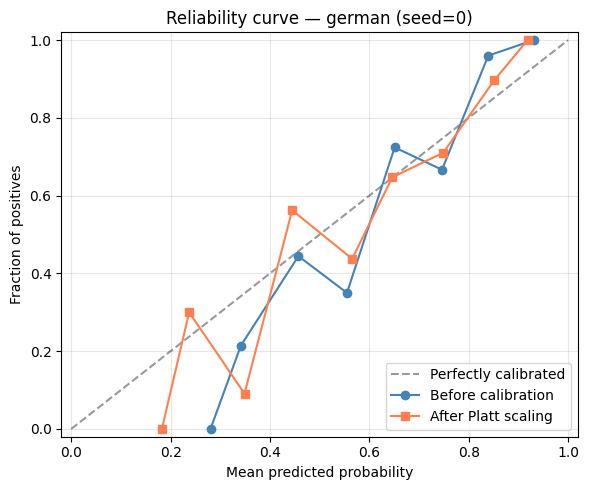

In [6]:
for ds_name, ds_df in per_run_df.groupby("dataset"):
    moran_vals = ds_df["moran_i_before"].values
    med_moran = np.median(moran_vals)
    rep_idx = int(np.argmin(np.abs(moran_vals - med_moran)))
    rep_run = ds_df.iloc[rep_idx]["run"]

    dataset_dir = RESULTS_DIR / ds_name
    run_dirs = _get_run_dirs(dataset_dir)
    rep_run_dir = [rd for rd in run_dirs if rd.name == rep_run][0]

    P_sel, P_cal = calibrate_predictions_for_run(rep_run_dir, ds_name, K=K)
    y_test = _get_test_labels(ds_name, rep_run_dir)

    p_before = P_sel.mean(axis=0)
    p_after = P_cal.mean(axis=0)

    n_bins = 10
    frac_pos_before, mean_pred_before = calibration_curve(y_test, p_before, n_bins=n_bins, strategy="uniform")
    frac_pos_after, mean_pred_after = calibration_curve(y_test, p_after, n_bins=n_bins, strategy="uniform")

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Perfectly calibrated")
    ax.plot(mean_pred_before, frac_pos_before, "o-", color="steelblue", label="Before calibration")
    ax.plot(mean_pred_after, frac_pos_after, "s-", color="coral", label="After Platt scaling")
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Fraction of positives")
    ax.set_title(f"Reliability curve — {ds_name} ({rep_run})")
    ax.legend(loc="lower right")
    ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)
    ax.grid(alpha=0.3)
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"calibration_reliability_{ds_name}.pdf", bbox_inches="tight")
    plt.show()

## 7. HH movement in feature space

PCA scatter of X_test for a representative run showing four categories: stable non-HH, HH before only, HH after only, HH both (overlap).

c:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\.venv\Lib\site-packages\libpysal\weights\distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)
c:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\.venv\Lib\site-packages\libpysal\weights\distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


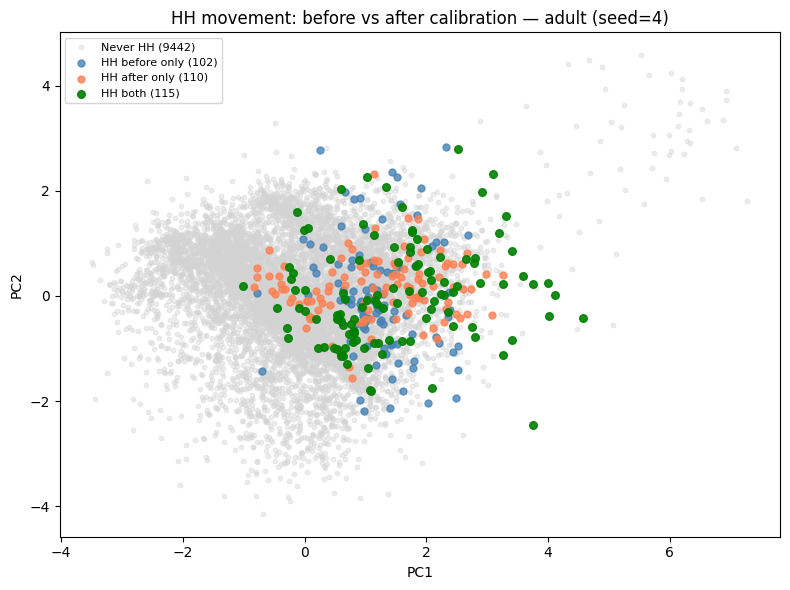

adult (seed=4): never HH=9442, before only=102, after only=110, both=115


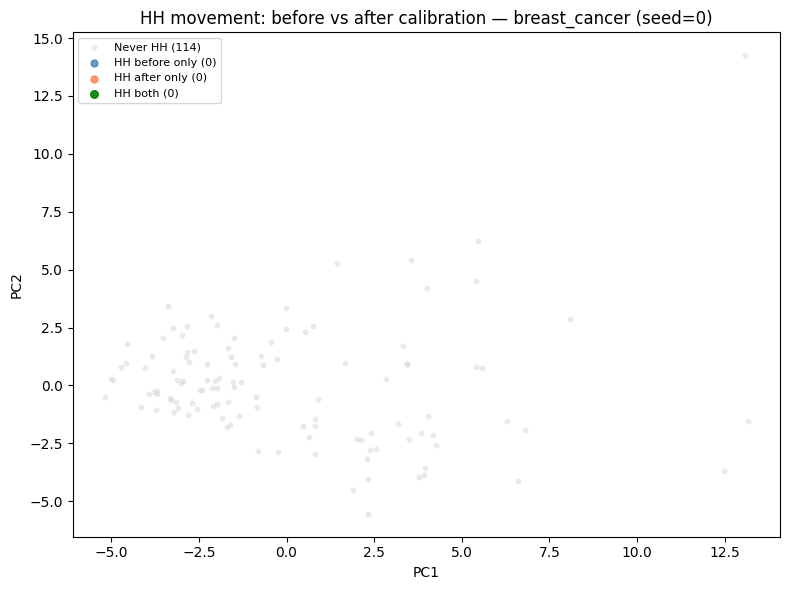

breast_cancer (seed=0): never HH=114, before only=0, after only=0, both=0


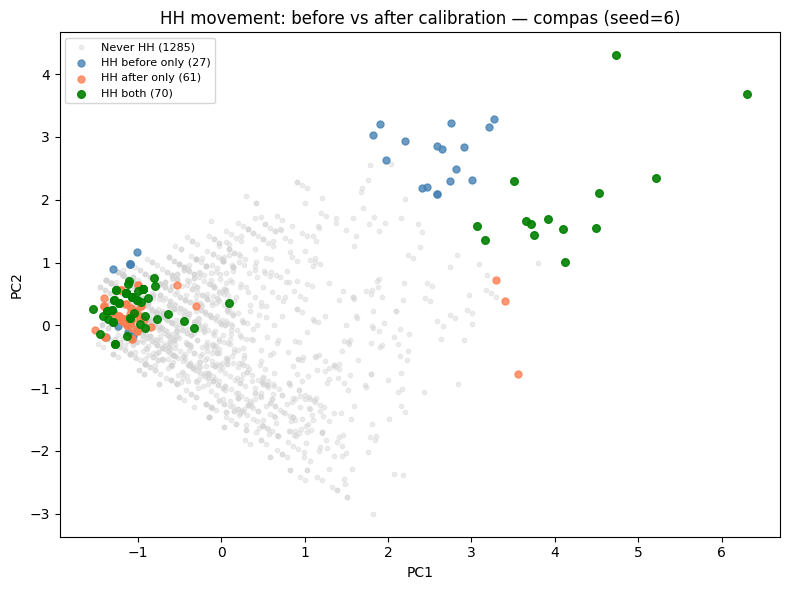

compas (seed=6): never HH=1285, before only=27, after only=61, both=70


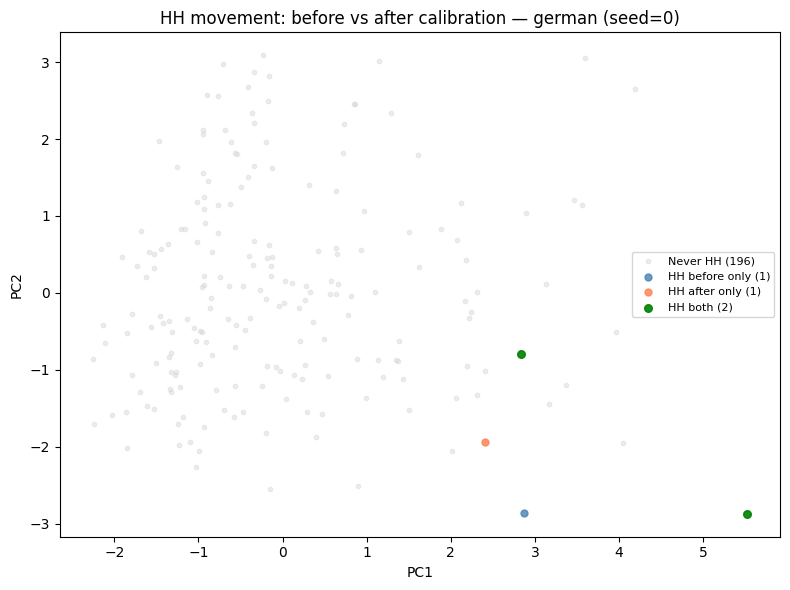

german (seed=0): never HH=196, before only=1, after only=1, both=2


In [7]:
for ds_name, ds_df in per_run_df.groupby("dataset"):
    moran_vals = ds_df["moran_i_before"].values
    med_moran = np.median(moran_vals)
    rep_idx = int(np.argmin(np.abs(moran_vals - med_moran)))
    rep_run = ds_df.iloc[rep_idx]["run"]

    dataset_dir = RESULTS_DIR / ds_name
    run_dirs = _get_run_dirs(dataset_dir)
    rep_run_dir = [rd for rd in run_dirs if rd.name == rep_run][0]

    P_sel, P_cal = calibrate_predictions_for_run(rep_run_dir, ds_name, K=K)
    X_test = get_transformed_test_features(rep_run_dir, ds_name)
    k_nn = 30

    v_before = pointwise_variance(P_sel, ddof=0)
    v_after = pointwise_variance(P_cal, ddof=0)

    sp_before = spatial_analysis(v_before, X_test, k=k_nn, permutations=999, fdr_alpha=0.05, seed=42)
    sp_after = spatial_analysis(v_after, X_test, k=k_nn, permutations=999, fdr_alpha=0.05, seed=42)

    hh_before = sp_before["HH_mask"]
    hh_after = sp_after["HH_mask"]

    both = hh_before & hh_after
    before_only = hh_before & ~hh_after
    after_only = ~hh_before & hh_after
    neither = ~hh_before & ~hh_after

    n_features = X_test.shape[1]
    if n_features > 2:
        pca = PCA(n_components=2, random_state=42)
        coords = pca.fit_transform(X_test)
    else:
        coords = np.asarray(X_test)

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(coords[neither, 0], coords[neither, 1], c="lightgray", s=10, alpha=0.4, label=f"Never HH ({int(neither.sum())})")
    ax.scatter(coords[before_only, 0], coords[before_only, 1], c="steelblue", s=25, alpha=0.8, label=f"HH before only ({int(before_only.sum())})")
    ax.scatter(coords[after_only, 0], coords[after_only, 1], c="coral", s=25, alpha=0.8, label=f"HH after only ({int(after_only.sum())})")
    ax.scatter(coords[both, 0], coords[both, 1], c="green", s=30, alpha=0.9, label=f"HH both ({int(both.sum())})")
    ax.set_xlabel("PC1" if n_features > 2 else "Feature 1")
    ax.set_ylabel("PC2" if n_features > 2 else "Feature 2")
    ax.set_title(f"HH movement: before vs after calibration — {ds_name} ({rep_run})")
    ax.legend(loc="best", fontsize=8)
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"calibration_hh_switch_pca_{ds_name}.pdf", bbox_inches="tight")
    plt.show()

    print(f"{ds_name} ({rep_run}): never HH={int(neither.sum())}, before only={int(before_only.sum())}, "
          f"after only={int(after_only.sum())}, both={int(both.sum())}")

## 8. Summary tables

Save per-run and aggregated calibration summary tables under tables/.

In [8]:
per_run_df.to_csv(TABLE_DIR / "calibration_per_run.csv", index=False)
summary_df.to_csv(TABLE_DIR / "calibration_summary.csv", index=False)
print(f"Saved: {TABLE_DIR / 'calibration_per_run.csv'}")
print(f"Saved: {TABLE_DIR / 'calibration_summary.csv'}")
print()
print("Per-run table shape:", per_run_df.shape)
display(per_run_df.head())
print()
print("Summary table:")
display(summary_df)

Saved: c:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\tables\calibration_per_run.csv
Saved: c:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\tables\calibration_summary.csv

Per-run table shape: (40, 28)


,run,brier_before,brier_after,brier_improvement,mean_variance_before,mean_variance_after,delta_mean_variance,mean_conflict_before,mean_conflict_after,delta_mean_conflict,...,disagreement_rate_before,disagreement_rate_after,discrepancy_before,discrepancy_after,jaccard_HH_before_after,n_components_before,n_components_after,max_component_size_before,max_component_size_after,dataset
0,seed=0,0.088879,0.091190,-0.002311,0.001461,0.001754,0.000293,0.016501,0.016100,-0.000401,...,0.138746,0.120992,0.045692,0.038608,0.459459,4,3,18,49,adult
1,seed=1,0.087408,0.089357,-0.001948,0.001306,0.001560,0.000253,0.016747,0.015797,-0.000950,...,0.142327,0.122541,0.054616,0.043683,0.555270,4,2,154,259,adult
2,seed=2,0.087919,0.090867,-0.002947,0.001474,0.001764,0.000290,0.018008,0.017173,-0.000835,...,0.151163,0.124220,0.061630,0.048988,0.396285,5,5,90,147,adult
3,seed=3,0.089963,0.092539,-0.002577,0.001587,0.001890,0.000303,0.019060,0.018045,-0.001015,...,0.159343,0.131639,0.056750,0.047307,0.398671,4,5,92,129,adult
4,seed=4,0.088864,0.091480,-0.002616,0.001433,0.001689,0.000256,0.018135,0.017336,-0.000798,...,0.150443,0.126074,0.053568,0.044013,0.351682,5,4,97,144,adult



Summary table:


,metric,mean,std,mean_plus_minus_std,dataset
0,delta_mean_variance,0.000313,0.000049,0.0003 ± 0.0000,adult
1,delta_moran_i,0.001906,0.006744,0.0019 ± 0.0067,adult
2,delta_n_HH,15.000000,27.988093,15.0000 ± 27.9881,adult
3,jaccard_HH_before_after,0.426762,0.064754,0.4268 ± 0.0648,adult
4,brier_improvement,-0.002594,0.000315,-0.0026 ± 0.0003,adult
5,delta_mean_variance,0.002112,0.001775,0.0021 ± 0.0018,breast_cancer
6,delta_moran_i,-0.012794,0.022489,-0.0128 ± 0.0225,breast_cancer
7,delta_n_HH,-1.200000,2.820559,-1.2000 ± 2.8206,breast_cancer
8,jaccard_HH_before_after,0.808333,0.355838,0.8083 ± 0.3558,breast_cancer
9,brier_improvement,-0.000342,0.002015,-0.0003 ± 0.0020,breast_cancer


## 9. Interpretation

- **If spatial metrics remain similar after calibration** (small Δ Moran's I, Δ HH count; high Jaccard overlap): multiplicity is **structural** — disagreement and clustering are not mainly due to probability miscalibration.

- **If spatial clustering weakens substantially** after calibration (Moran's I drops, HH count drops, low Jaccard): the effect is **partly due to miscalibration** — calibrating probabilities reduces both overall spread and the spatial concentration of disagreement.

Use the aggregated summary (Δ mean_variance, Δ Moran's I, Δ HH count, mean Jaccard) to draw conclusions for the dataset.